In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Note:** 
## I am going to work on data refinement and finding the actual road closures, or atleast what is a road closure with high probability.

In [26]:
closures = pd.read_csv("/Users/hudson/Desktop/road_project/data/extracted_data/possible_closures.csv")

In [38]:
closures[closures["duration_minutes"] > 1000].head()

,Station,closure_date,start_time,end_time,duration_minutes,n_intervals,mean_flow,mean_speed,max_occupancy,multi_station_event
238,316261,2013-03-28,2013-03-28 01:20:00,2013-03-28 23:55:00,1360.0,236,0.016949,67.198729,0.0051,True
247,316261,2013-04-07,2013-04-07 01:45:00,2013-04-07 23:55:00,1335.0,251,0.302789,68.103187,0.0070,True
379,317791,2013-11-22,2013-11-22 04:20:00,2013-11-22 23:55:00,1180.0,236,0.000000,68.000000,0.0000,False
391,317797,2013-12-03,2013-12-03 02:25:00,2013-12-03 23:55:00,1295.0,3,4.333333,66.266667,0.0034,False
485,317797,2014-02-06,2014-02-06 01:25:00,2014-02-06 19:35:00,1095.0,53,3.264151,67.816981,0.0164,True


In [27]:
daily_max = (
    closures.loc[
        closures.groupby("closure_date")["duration_minutes"].idxmax()
    ]
    .sort_values("closure_date")
    .reset_index(drop=True)
)

In [31]:
dailyMaxArray = np.array(daily_max["duration_minutes"])
bottom10th = np.percentile(dailyMaxArray, 10)

(array([187., 124.,  82.,  52.,  46.,  42.,  38.,  39.,  47.,  64.,  54.,
         48.,  55.,  62.,  61.,  76.,  96.,  96.,  68.,  63.,  65.,  66.,
         62.,  59.,  40.,  54.,  41.,  24.,  38.,  27.,  24.,  21.,  10.,
          4.,   9.,  12.,   7.,   4.,   3.,   5.,   1.,   3.,   1.,   0.,
          2.,   0.,   1.,   2.,   1.,   0.,   1.,   1.,   0.,   3.,   0.,
          1.,   0.,   3.,   0.,   2.,   1.,   0.,   2.,   0.,   0.,   1.,
          1.,   0.,   0.,   1.,   0.,   0.,   1.,   0.,   0.,   1.,   2.,
          0.,   0.,   1.,   2.,   2.,   2.,   3.,   2.,   1.,   0.,   0.,
          0.,   2.,   2.,   0.,   2.,   0.,   2.,   1.,   1.,   2.,   1.,
          0.,   1.,   1.,   0.,   0.,   1.,   2.,   0.,   0.,   0.,   1.,
          1.,   0.,   0.,   1.,   2.,   0.,   3.,   4.,   2.,   2.,   2.,
          1.,   3.,   4.,   1.,   6.,   8.,   1.,   8.,   6.,   4.,   2.,
          7.,  13.,   9.,   5.,   7.,  13.,  11.,  21., 106., 451.,  49.,
        276.,   0.,   0.,   0.,   0., 

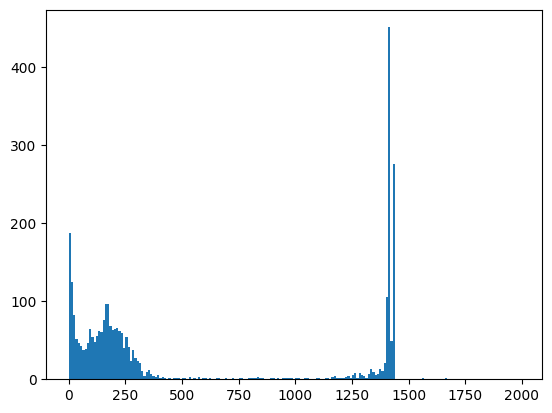

In [37]:
plt.hist(dailyMaxArray, bins = np.arange(0, 2000, 10))

# **Dead End:**
## It will be hard to get usable closure data from this, alot of the data is clustered around a 24 hour closure, which ARE NOT this common. Clearly our data extraction is too difficult for an algorithm to handle, as there are too many variables.